

# Fraud Detection & Transaction Risk Scoring




## DATA UNDERSTANDING


In [39]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from xgboost import XGBClassifier

# SHAP untuk explainability
import shap

# Setting visualisasi
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load DATASET

In [40]:
df = pd.read_csv("https://raw.githubusercontent.com/iyungalam/Fraud-Analysis/refs/heads/main/Fraud.csv", sep=';')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Data Understandng

In [41]:
print("Jumlah baris    :", df.shape[0])
print("Jumlah kolom    :", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Jumlah baris    : 1048575
Jumlah kolom    : 11

Nama kolom:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  object 
 5   newbalanceOrig  1048575 non-null  object 
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  object 
 8   newbalanceDest  1048575 non-null  object 
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memor

In [42]:
#Statistik Deskriptif
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,1048575.0,NaN,NaN,NaN,26.966174,15.623252,1.0,15.0,20.0,39.0,95.0
type,1048575,5,CASH_OUT,373641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,1048575.0,NaN,NaN,NaN,158666.975527,264940.930363,0.1,12149.065,76343.33,213761.89,10000000.0
nameOrig,1048575,1048317,C443816828,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,1048575,391375,0.0,342214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
newbalanceOrig,1048575,441140,0.0,580275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nameDest,1048575,449635,C985934102,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,1048575,590388,0.0,437134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
newbalanceDest,1048575,437293,0.0,406914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isFraud,1048575.0,NaN,NaN,NaN,0.001089,0.032984,0.0,0.0,0.0,0.0,1.0


In [43]:
#  MISSING VALUE CHECK

missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    by="Missing",
    ascending=False
)

display(missing)

,Missing,Percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [44]:
# DUPLICATE CHECK

duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)

Jumlah duplicate: 0


## Data Cleaning


In [45]:

balance_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for col in balance_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df.dtypes)

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [46]:
# TARGET DISTRIBUTION

fraud_count = df["isFraud"].value_counts()

print(fraud_count)

fraud_percentage = (
    df["isFraud"].value_counts(normalize=True) * 100
)

print("\nPersentase:")
print(fraud_percentage)

isFraud
0    1047433
1       1142
Name: count, dtype: int64

Persentase:
isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64


In [47]:
target_summary = pd.DataFrame({
    "Count": df["isFraud"].value_counts(),
    "Percentage": df["isFraud"].value_counts(normalize=True) * 100
})

display(target_summary)

,Count,Percentage
isFraud,,
0,1047433,99.89109
1,1142,0.10891


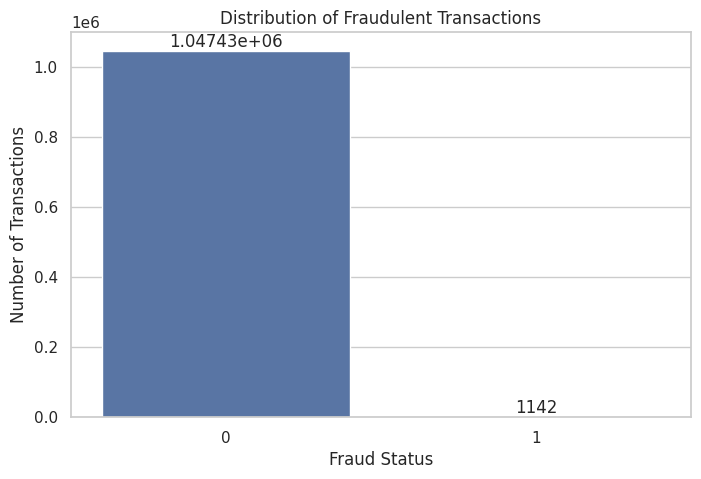

In [49]:
# FRAUD DISTRIBUTION

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Distribution of Fraudulent Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Exploratory Data Analyst


### Fraud Berdasarkan Jenis Transaksi

In [50]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

display(fraud_by_type)

isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353873,0
TRANSFER,86189,564


In [51]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total_Transactions",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

fraud_rate_by_type["Fraud_Rate"] *= 100

display(
    fraud_rate_by_type.sort_values(
        "Fraud_Rate",
        ascending=False
    )
)

,Total_Transactions,Fraud_Count,Fraud_Rate
type,,,
TRANSFER,86753,564,0.650122
CASH_OUT,373641,578,0.154694
CASH_IN,227130,0,0.000000
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000


In [52]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total_Transactions",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

fraud_rate_by_type["Fraud_Rate"] *= 100

display(
    fraud_rate_by_type.sort_values(
        "Fraud_Rate",
        ascending=False
    )
)

,Total_Transactions,Fraud_Count,Fraud_Rate
type,,,
TRANSFER,86753,564,0.650122
CASH_OUT,373641,578,0.154694
CASH_IN,227130,0,0.000000
DEBIT,7178,0,0.000000
PAYMENT,353873,0,0.000000


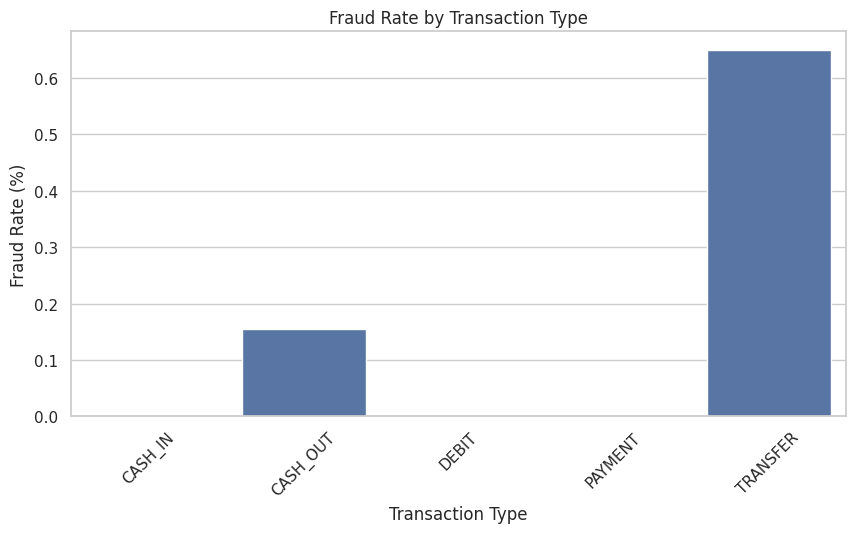

In [53]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_rate_by_type.reset_index(),
    x="type",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Analisis Nominal Transaksi

In [54]:
amount_summary = (
    df.groupby("isFraud")["amount"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

display(amount_summary)

,count,mean,median,min,max
isFraud,,,,,
0,1047433,1.575397e+05,76214.97,0.1,6419835.27
1,1142,1.192629e+06,353179.45,119.0,10000000.00


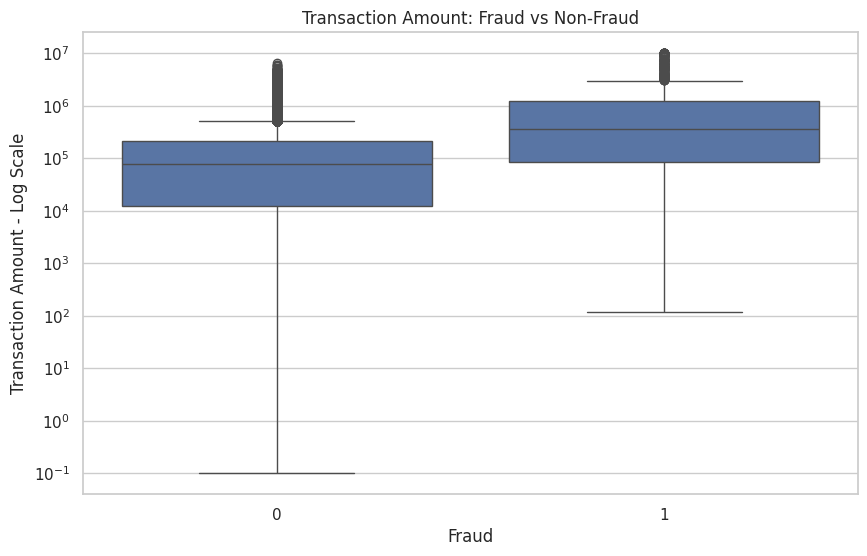

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title(
    "Transaction Amount: Fraud vs Non-Fraud"
)

plt.xlabel("Fraud")
plt.ylabel("Transaction Amount - Log Scale")

plt.show()

### Analisis Fraud Berdasarkan Waktu

In [56]:

fraud_by_step = (
    df.groupby("step")["isFraud"]
    .agg(["count", "sum", "mean"])
)

fraud_by_step["mean"] *= 100

fraud_by_step.rename(
    columns={
        "count": "Total_Transactions",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    },
    inplace=True
)

display(fraud_by_step.head())

,Total_Transactions,Fraud_Count,Fraud_Rate
step,,,
1,2708,16,0.590842
2,1014,8,0.788955
3,552,4,0.724638
4,565,10,1.769912
5,665,6,0.902256


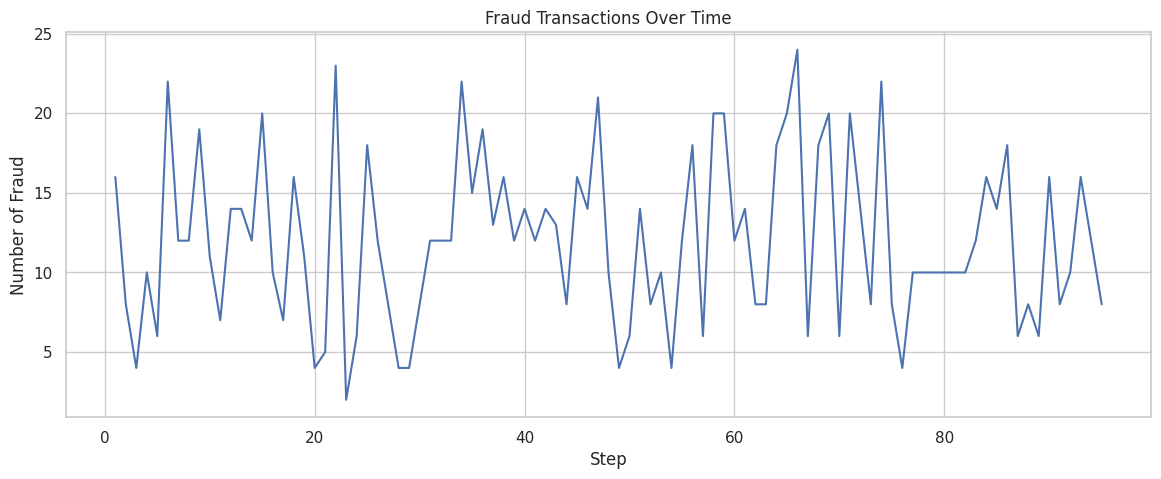

In [57]:
plt.figure(figsize=(14, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["Fraud_Count"]
)

plt.title("Fraud Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraud")

plt.show()

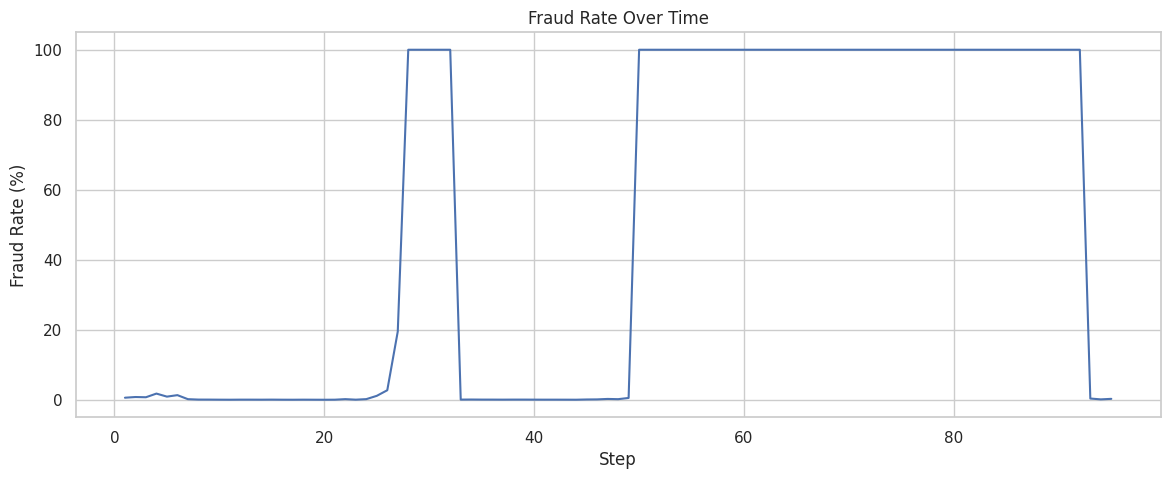

In [59]:
plt.figure(figsize=(14, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["Fraud_Rate"]
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

## Feature Engineering

Pertanyaan 1: Jenis transaksi apa yang paling sering fraud?

Pertanyaan 2: Apakah fraud memiliki nominal transaksi lebih tinggi?

Pertanyaan 3: Apakah fraud sering menghabiskan saldo?

Pertanyaan 4: Apakah fraud terjadi pada waktu tertentu?

In [60]:
# FEATURE ENGINEERING

df_model = df.copy()

# Perubahan saldo pengirim

df_model["balance_change_orig"] = (
    df_model["oldbalanceOrg"]
    - df_model["newbalanceOrig"]
)

# Perubahan saldo penerima

df_model["balance_change_dest"] = (
    df_model["newbalanceDest"]
    - df_model["oldbalanceDest"]
)

# Rasio transaksi terhadap saldo awal

df_model["amount_balance_ratio"] = (
    df_model["amount"] /
    (df_model["oldbalanceOrg"] + 1)
)

# Rasio penggunaan saldo

df_model["balance_usage_ratio"] = (
    df_model["balance_change_orig"] /
    (df_model["oldbalanceOrg"] + 1)
)

# Apakah saldo pengirim menjadi 0?

df_model["is_zero_balance_after"] = (
    df_model["newbalanceOrig"] == 0
).astype(int)

# Apakah saldo awal pengirim 0?

df_model["is_zero_balance_before"] = (
    df_model["oldbalanceOrg"] == 0
).astype(int)

# Apakah transaksi melebihi saldo?

df_model["amount_exceeds_balance"] = (
    df_model["amount"] >
    df_model["oldbalanceOrg"]
).astype(int)

# Selisih saldo pengirim

df_model["orig_balance_error"] = (
    df_model["oldbalanceOrg"]
    - df_model["amount"]
    - df_model["newbalanceOrig"]
)

# Selisih saldo penerima

df_model["dest_balance_change_error"] = (
    df_model["newbalanceDest"]
    - df_model["oldbalanceDest"]
    - df_model["amount"]
)

display(df_model.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_change_orig,balance_change_dest,amount_balance_ratio,balance_usage_ratio,is_zero_balance_after,is_zero_balance_before,amount_exceeds_balance,orig_balance_error,dest_balance_change_error
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.057834,0.057834,0,0,0,0.0,-9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.087731,0.087731,0,0,0,0.0,-1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0.994505,0.994505,1,0,0,0.0,-181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,0.994505,0.994505,1,0,0,0.0,-21363.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0.280788,0.280788,0,0,0,0.0,-11668.14


## Feature Selection

### Feature Engineering Berbasis Tipe Transaksi

In [61]:

df_model["is_transfer"] = (
    df_model["type"] == "TRANSFER"
).astype(int)

df_model["is_cashout"] = (
    df_model["type"] == "CASH_OUT"
).astype(int)

df_model["is_payment"] = (
    df_model["type"] == "PAYMENT"
).astype(int)

df_model["is_debit"] = (
    df_model["type"] == "DEBIT"
).astype(int)

df_model["is_cash_in"] = (
    df_model["type"] == "CASH_IN"
).astype(int)

### Analisis Feature Engineering

In [62]:
# FEATURE VS FRAUD

engineered_features = [
    "balance_change_orig",
    "balance_change_dest",
    "amount_balance_ratio",
    "balance_usage_ratio",
    "is_zero_balance_after",
    "is_zero_balance_before",
    "amount_exceeds_balance"
]

display(
    df_model.groupby("isFraud")[engineered_features]
    .mean()
    .T
)

isFraud,0,1
balance_change_orig,-17681.101285,1.130344e+06
balance_change_dest,124914.334532,5.603842e+05
amount_balance_ratio,57293.176408,7.530478e+03
balance_usage_ratio,-527.699550,9.812469e-01
is_zero_balance_after,0.552916,9.921191e-01
is_zero_balance_before,0.326698,1.751313e-02
amount_exceeds_balance,0.625315,2.101576e-02


In [63]:
# SELECT FEATURES

features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "balance_change_orig",
    "balance_change_dest",
    "amount_balance_ratio",
    "balance_usage_ratio",
    "is_zero_balance_after",
    "is_zero_balance_before",
    "amount_exceeds_balance",
    "orig_balance_error",
    "dest_balance_change_error",
    "is_transfer",
    "is_cashout",
    "is_payment",
    "is_debit",
    "is_cash_in"
]

X = df_model[features].copy()
y = df_model["isFraud"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1048575, 21)
y shape: (1048575,)


In [64]:
# FINAL MISSING VALUE CHECk

missing_model = X.isnull().sum()

display(
    missing_model[
        missing_model > 0
    ]
)

,0
oldbalanceOrg,25173
newbalanceOrig,25885
oldbalanceDest,14090
newbalanceDest,15802
balance_change_orig,25892
balance_change_dest,15995
amount_balance_ratio,25173
balance_usage_ratio,25892
orig_balance_error,25892
dest_balance_change_error,15995


In [65]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

In [66]:
# FINAL MISSING VALUE CHECK

missing_model = X.isnull().sum()

display(
    missing_model[
        missing_model > 0
    ]
)

,0


## Train-Test Split

In [67]:
# TIME-BASED TRAIN TEST SPLIT

split_step = df_model["step"].quantile(0.80)

train_mask = df_model["step"] <= split_step
test_mask = df_model["step"] > split_step

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nFraud train:")
print(y_train.value_counts())

print("\nFraud test:")
print(y_test.value_counts())

Train: (859287, 21)
Test : (189288, 21)

Fraud train:
isFraud
0    858803
1       484
Name: count, dtype: int64

Fraud test:
isFraud
0    188630
1       658
Name: count, dtype: int64


## Class Imbalance

In [68]:
# CLASS IMBALANCE

print("Training distribution:")
display(
    pd.DataFrame({
        "Count": y_train.value_counts(),
        "Percentage": y_train.value_counts(normalize=True) * 100
    })
)

Training distribution:


,Count,Percentage
isFraud,,
0,858803,99.943674
1,484,0.056326


### Hitung scale_pos_weight

In [69]:
# SCALE POS WEIGHT

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

scale_pos_weight: 1774.3863636363637


## Model Logistic Regression

In [70]:
# LOGISTIC REGRESSION BASELINE

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_pred = (
    logistic_prob >= 0.5
).astype(int)

In [103]:
print(
    classification_report(
        y_test,
        logistic_pred,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        logistic_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        logistic_prob
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999    188630
           1     0.9292    0.9970    0.9619       658

    accuracy                         0.9997    189288
   macro avg     0.9646    0.9983    0.9809    189288
weighted avg     0.9997    0.9997    0.9997    189288

ROC-AUC: 0.999536709020264
PR-AUC: 0.998259158955007


## Model XGBoost

In [72]:
# XGBOOST

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

In [73]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

In [74]:
# XGBOOST PREDICTION

y_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= 0.5
).astype(int)

In [75]:
# MODEL EVALUATION

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("ROC-AUC :", round(roc_auc, 4))
print("PR-AUC  :", round(pr_auc, 4))

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    188630
           1     1.0000    0.9970    0.9985       658

    accuracy                         1.0000    189288
   macro avg     1.0000    0.9985    0.9992    189288
weighted avg     1.0000    1.0000    1.0000    189288

ROC-AUC : 0.9986
PR-AUC  : 0.9971


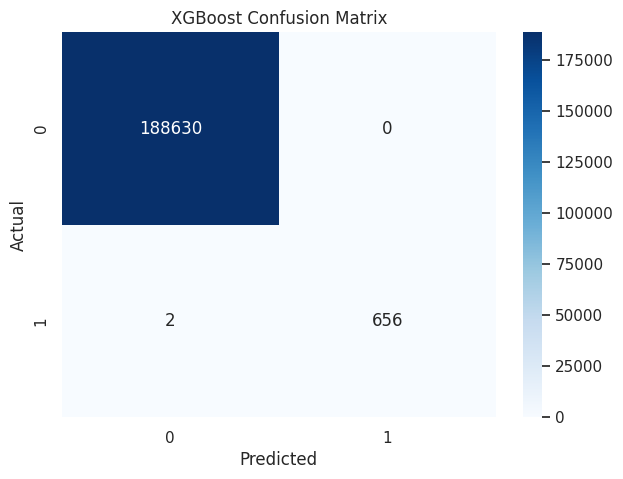

In [77]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

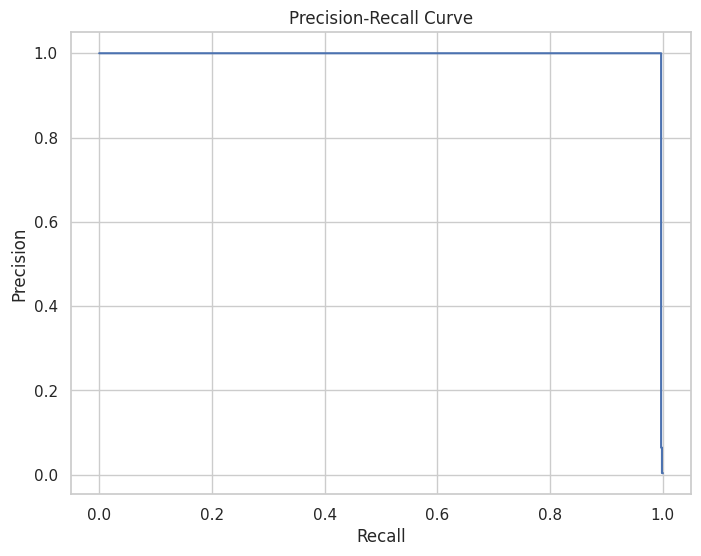

In [78]:
# PRECISION-RECALL CURVE

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

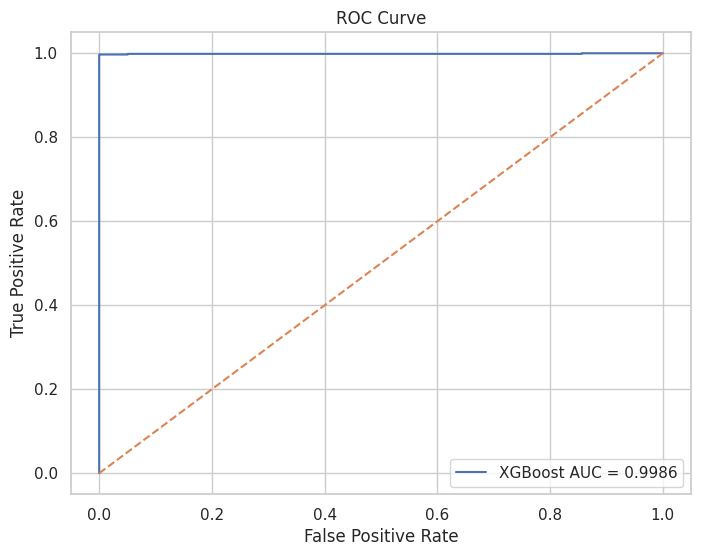

In [79]:
# ROC CURVE

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Threshold Optimization

In [80]:
# THRESHOLD OPTIMIZATION

threshold_results = []

for threshold in np.arange(
    0.05,
    0.96,
    0.05
):

    pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    precision_value = precision_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1": f1_value
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.05,0.996960,0.99696,0.996960
1,0.10,0.998478,0.99696,0.997719
2,0.15,0.998478,0.99696,0.997719
3,0.20,1.000000,0.99696,0.998478
4,0.25,1.000000,0.99696,0.998478
5,0.30,1.000000,0.99696,0.998478
6,0.35,1.000000,0.99696,0.998478
7,0.40,1.000000,0.99696,0.998478
8,0.45,1.000000,0.99696,0.998478
9,0.50,1.000000,0.99696,0.998478


In [81]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

display(best_threshold_row)

,3
Threshold,0.200000
Precision,1.000000
Recall,0.996960
F1,0.998478


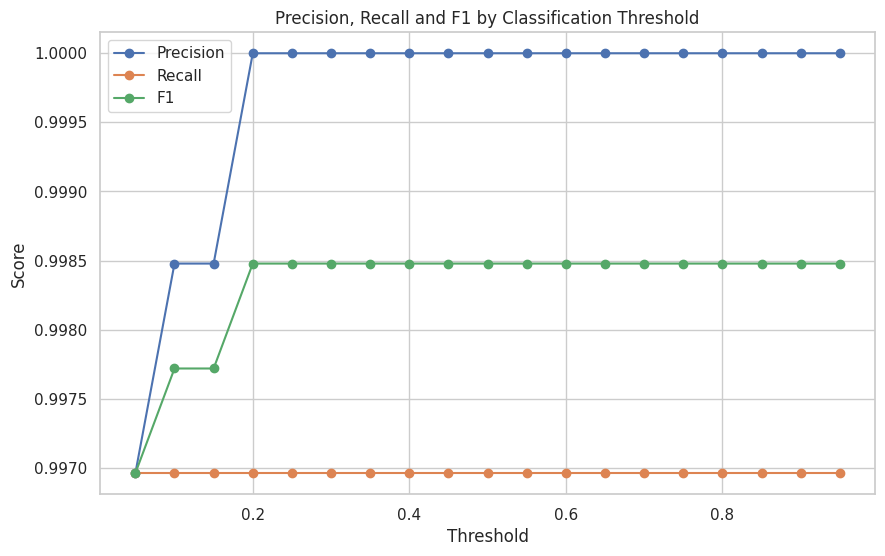

In [82]:
# THRESHOLD PERFORMANCE

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 by Classification Threshold"
)

plt.legend()

plt.show()

In [83]:
# FINAL THRESHOLD

optimal_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    "Optimal Threshold:",
    optimal_threshold
)

y_pred_optimal = (
    y_prob >= optimal_threshold
).astype(int)

Optimal Threshold: 0.2


In [85]:
print(
    classification_report(
        y_test,
        y_pred_optimal,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    188630
           1     1.0000    0.9970    0.9985       658

    accuracy                         1.0000    189288
   macro avg     1.0000    0.9985    0.9992    189288
weighted avg     1.0000    1.0000    1.0000    189288



## Feature Importance

In [86]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(feature_importance)

,Feature,Importance
11,is_zero_balance_after,0.309910
10,balance_usage_ratio,0.166114
14,orig_balance_error,0.154735
13,amount_exceeds_balance,0.144185
12,is_zero_balance_before,0.051830
7,balance_change_orig,0.030762
20,is_cash_in,0.022564
4,oldbalanceDest,0.015950
16,is_transfer,0.013890
3,newbalanceOrig,0.013769


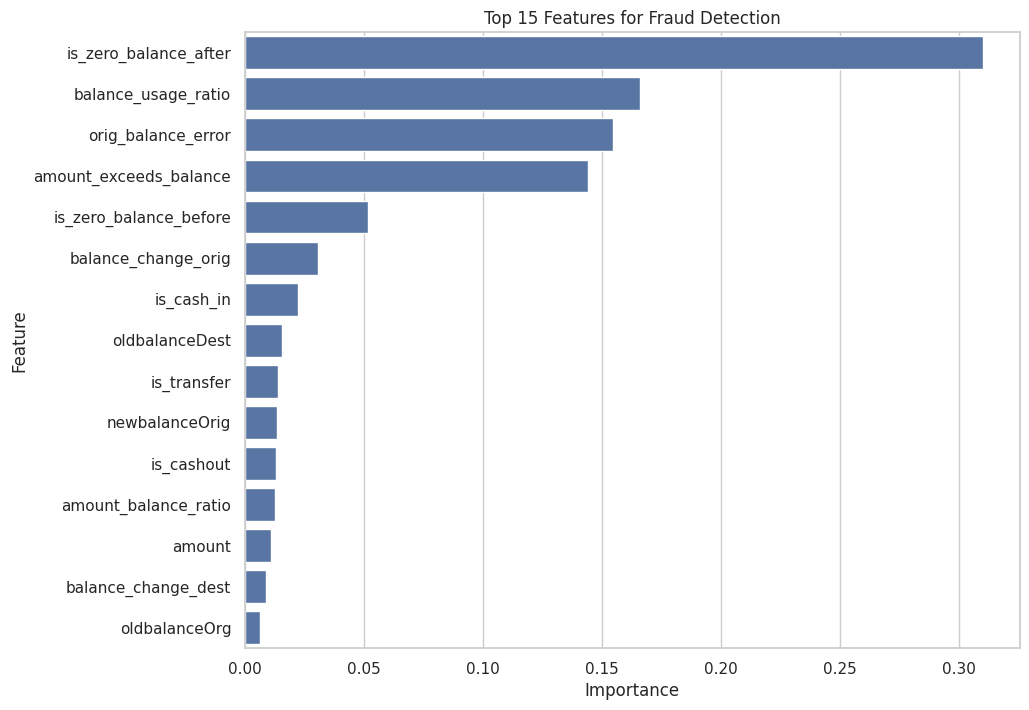

In [87]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features for Fraud Detection"
)

plt.show()

## SHAP Explainability

In [88]:
!pip install shap

In [89]:
# SHAP EXPLAINABILITY

explainer = shap.TreeExplainer(
    xgb_model
)

# Gunakan sample agar SHAP tidak terlalu berat
X_shap = X_test.sample(
    min(5000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

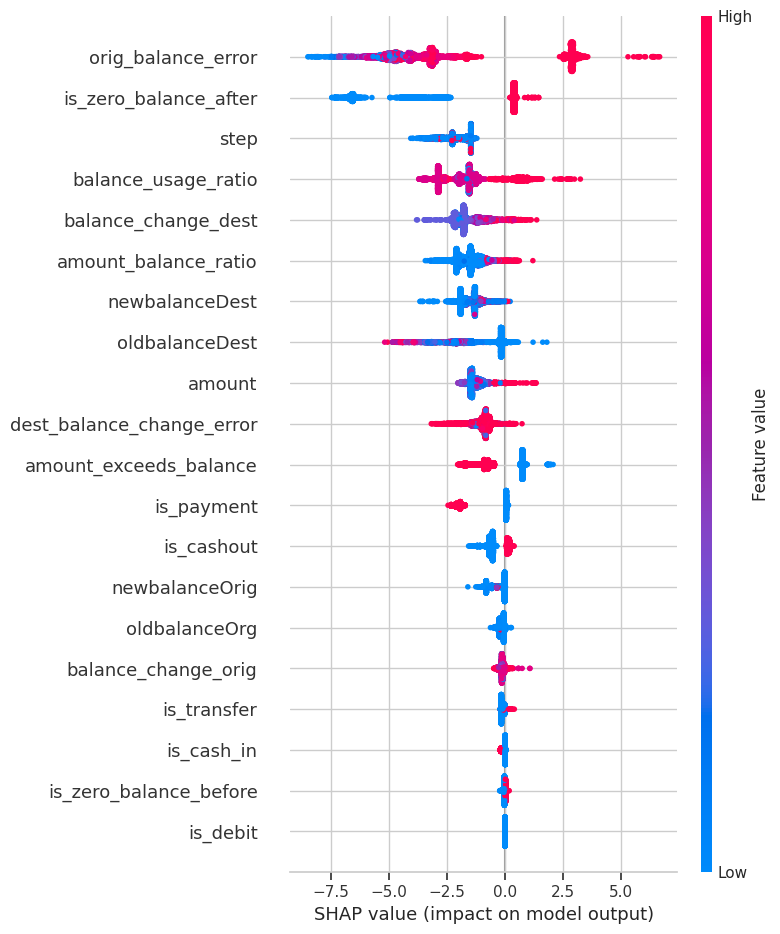

In [90]:
# SHAP SUMMARY

shap.summary_plot(
    shap_values,
    X_shap
)

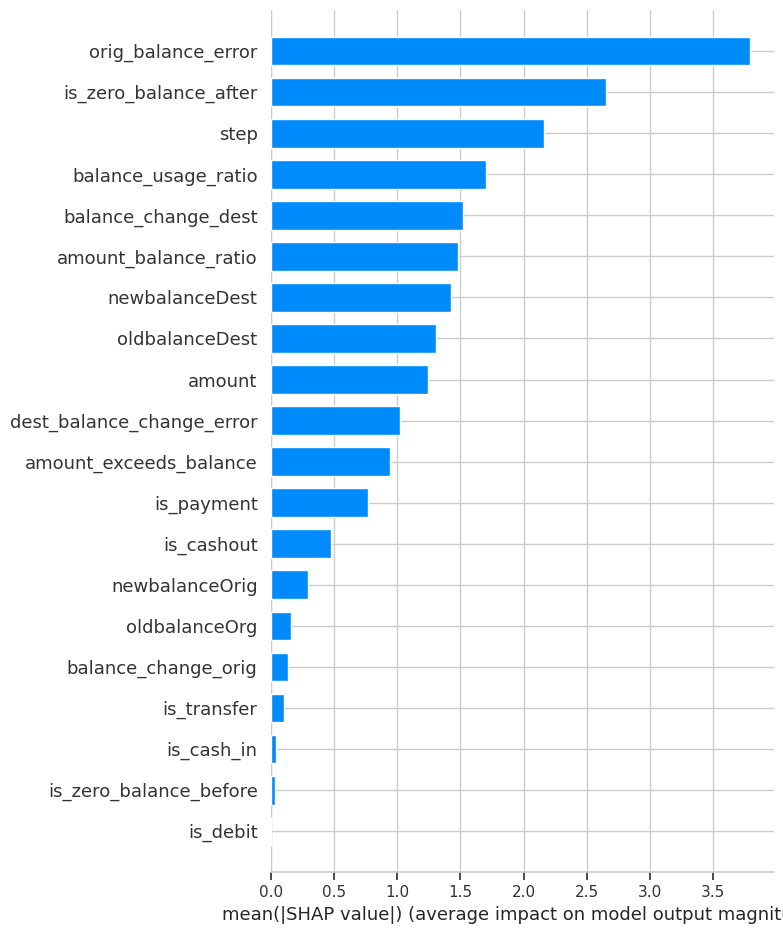

In [91]:
# SHAP FEATURE IMPORTANCE

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

## Fraud Risk Score

In [92]:
# FRAUD RISK SCORING

risk_df = X_test.copy()

risk_df["Actual_Fraud"] = y_test

risk_df["Fraud_Probability"] = y_prob

risk_df["Fraud_Probability_Pct"] = (
    risk_df["Fraud_Probability"] * 100
)

## Risk Classification

In [93]:
# 36. RISK CLASSIFICATION

def classify_risk(probability):

    if probability < 0.20:
        return "Low Risk"

    elif probability < 0.50:
        return "Medium Risk"

    elif probability < 0.80:
        return "High Risk"

    else:
        return "Critical Risk"


risk_df["Risk_Level"] = (
    risk_df["Fraud_Probability"]
    .apply(classify_risk)
)

## Bussiness Recommendation

In [94]:
# 37. RISK ACTION

def risk_action(risk):

    if risk == "Low Risk":
        return "Approve"

    elif risk == "Medium Risk":
        return "Monitor"

    elif risk == "High Risk":
        return "Enhanced Monitoring"

    else:
        return "Manual Investigation"


risk_df["Recommended_Action"] = (
    risk_df["Risk_Level"]
    .apply(risk_action)
)

In [95]:
display(
    risk_df[
        [
            "Actual_Fraud",
            "Fraud_Probability_Pct",
            "Risk_Level",
            "Recommended_Action"
        ]
    ].head(20)
)

,Actual_Fraud,Fraud_Probability_Pct,Risk_Level,Recommended_Action
859287,0,0.000010,Low Risk,Approve
859288,0,0.000031,Low Risk,Approve
859289,0,0.000105,Low Risk,Approve
859290,0,0.000449,Low Risk,Approve
859291,0,0.000032,Low Risk,Approve
859292,0,0.000142,Low Risk,Approve
859293,0,0.000162,Low Risk,Approve
859294,0,0.000271,Low Risk,Approve
859295,0,0.000278,Low Risk,Approve
859296,0,0.000093,Low Risk,Approve


In [96]:
# RISK LEVEL DISTRIBUTIN

risk_distribution = (
    risk_df["Risk_Level"]
    .value_counts()
)

display(risk_distribution)

,count
Risk_Level,
Low Risk,188632
Critical Risk,656


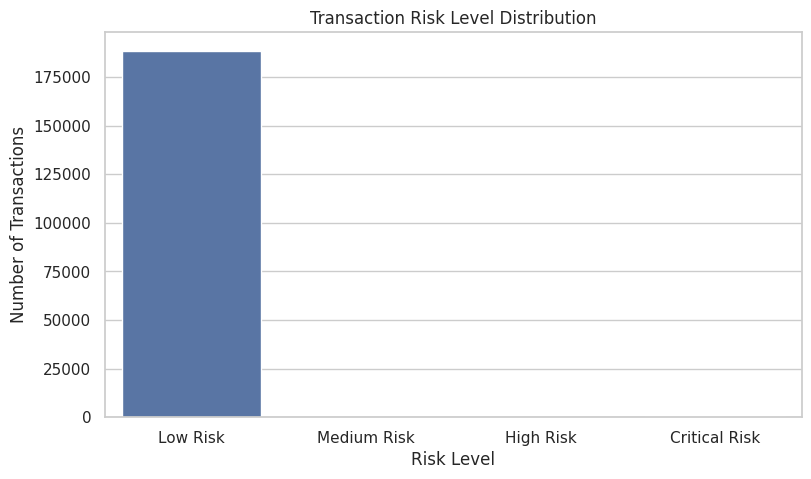

In [97]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=risk_df,
    x="Risk_Level",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Critical Risk"
    ]
)

plt.title(
    "Transaction Risk Level Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")

plt.show()

In [98]:
# HIGH RISK TRANSACTIONS

high_risk_transactions = (
    risk_df
    .sort_values(
        "Fraud_Probability",
        ascending=False
    )
    .head(100)
)

display(
    high_risk_transactions
)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_change_orig,balance_change_dest,amount_balance_ratio,balance_usage_ratio,is_zero_balance_after,is_zero_balance_before,amount_exceeds_balance,orig_balance_error,dest_balance_change_error,is_transfer,is_cashout,is_payment,is_debit,is_cash_in,Actual_Fraud,Fraud_Probability,Fraud_Probability_Pct,Risk_Level,Recommended_Action
1040185,94,1454592.61,1454592.61,0.0,0.0,0.0,0,1454592.61,0.0,0.999999,0.999999,1,0,0,0.0,-1454592.61,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1015713,47,2249574.01,2249574.01,0.0,0.0,0.0,0,2249574.01,0.0,1.000000,1.000000,1,0,0,0.0,-2249574.01,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1034627,93,3723738.06,3723738.06,0.0,0.0,0.0,0,3723738.06,0.0,1.000000,1.000000,1,0,0,0.0,-3723738.06,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
870140,42,1566057.28,1566057.28,0.0,0.0,0.0,0,1566057.28,0.0,0.999999,0.999999,1,0,0,0.0,-1566057.28,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1030269,51,1398946.33,1398946.33,0.0,0.0,0.0,0,1398946.33,0.0,0.999999,0.999999,1,0,0,0.0,-1398946.33,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
870089,42,3569720.42,3569720.42,0.0,0.0,0.0,0,3569720.42,0.0,1.000000,1.000000,1,0,0,0.0,-3569720.42,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1025193,48,1215297.01,1215297.01,0.0,0.0,0.0,0,1215297.01,0.0,0.999999,0.999999,1,0,0,0.0,-1215297.01,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1023029,47,1388951.50,1388951.50,0.0,0.0,0.0,0,1388951.50,0.0,0.999999,0.999999,1,0,0,0.0,-1388951.50,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
955157,44,1649818.97,1649818.97,0.0,0.0,0.0,0,1649818.97,0.0,0.999999,0.999999,1,0,0,0.0,-1649818.97,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation
1029538,49,1021129.67,1021129.67,0.0,0.0,0.0,0,1021129.67,0.0,0.999999,0.999999,1,0,0,0.0,-1021129.67,1,0,0,0,0,1,0.999999,99.999908,Critical Risk,Manual Investigation


In [99]:
# FRAUD RATE BY RISK LEVEL

risk_performance = (
    risk_df
    .groupby("Risk_Level")
    .agg(
        Total_Transactions=("Actual_Fraud", "count"),
        Fraud_Count=("Actual_Fraud", "sum"),
        Fraud_Rate=("Actual_Fraud", "mean")
    )
)

risk_performance["Fraud_Rate"] *= 100

risk_performance = risk_performance.reindex([
    "Low Risk",
    "Medium Risk",
    "High Risk",
    "Critical Risk"
])

display(risk_performance)

,Total_Transactions,Fraud_Count,Fraud_Rate
Risk_Level,,,
Low Risk,188632.0,2.0,0.00106
Medium Risk,NaN,NaN,NaN
High Risk,NaN,NaN,NaN
Critical Risk,656.0,656.0,100.00000


In [100]:
# MODEL COMPARISON

models_comparison = []

# Logistic Regression
models_comparison.append({
    "Model": "Logistic Regression",
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        logistic_prob
    ),
    "Precision": precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    )
})

# XGBoost
models_comparison.append({
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob
    ),
    "Precision": precision_score(
        y_test,
        y_pred_optimal,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_optimal,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_optimal,
        zero_division=0
    )
})

comparison_df = pd.DataFrame(
    models_comparison
)

display(comparison_df)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.999537,0.998259,0.929178,0.99696,0.961877
1,XGBoost,0.998622,0.997064,1.000000,0.99696,0.998478


In [101]:
# SAVE MODEL

import joblib

joblib.dump(
    xgb_model,
    "fraud_xgboost_model.pkl"
)

joblib.dump(
    optimal_threshold,
    "fraud_threshold.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


In [102]:
#  EXPORT RISK SCORING

risk_df.to_csv(
    "fraud_risk_scoring.csv",
    index=True
)

print(
    "Fraud risk scoring berhasil disimpan."
)

Fraud risk scoring berhasil disimpan.
